In [ ]:
import os
os.chdir('src') #<--------------------------fix this

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#user defined
from src.Ellipse2dObj import *
from src.animate import *
from src.trajectory import *
from src.simopt import *

#load data
from src import bbotData
#from bbotData import Ellipsoid
dfs, dtime, mps, la = bbotData.load()

#os.chdir('/home/isa/Documents/brainbot/bbcode/src')
from scipy.interpolate import interp1d
from scipy.optimize import least_squares

A1 = 2.75/100 #same as 
A2 = 1.5/100
rmag = np.sqrt(((1-0.592)*A1)**2+((1-0.390)*A2)**2)


DPI = 300
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.serif'] = ["Times New Roman"]  
plt.rcParams['font.size'] = 10
plt.rcParams['font.style'] = 'italic'

FileNotFoundError: [Errno 2] No such file or directory: '../bbot_data/'

<Figure size 1200x1200 with 0 Axes>

(0.47155647606392687,
 0.5481062303874905,
 -0.25970979167706165,
 -0.17734019508527177)

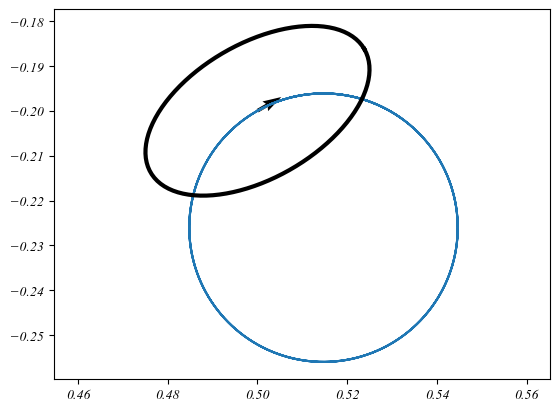

In [2]:
fw  = lambda t: -1 #define time-dependent velocity profiles
fv1 = lambda t: 0.02
fv2 = lambda t: 0.01
sim_time = 20
dt = 0.01


x0,y0, phi0 = 0.5, -0.2, np.deg2rad(30) #initial position
b0 = BBot(r=np.array([x0, y0]), theta_rad=phi0,
                vfunc1=fv1, vfunc2=fv2, wfunc=fw)

df = simulate_bbot(b0, sim_time, dt, 'CN', 'time')

plt.plot(df.X, df.Y)
plotBot(x0,y0,phi0)
plt.axis('equal')

(0.4660871153720759,
 0.6629628049163598,
 -0.30467448177307077,
 -0.1751990193664142)

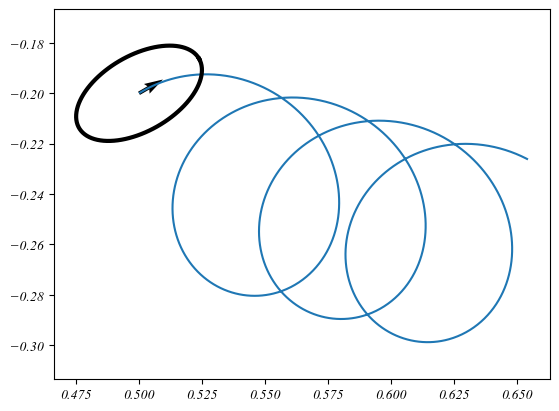

In [3]:

fw  = lambda t: -1
fv1 = lambda t: 0.03 + 0.008*np.cos(fw(t)*t)
fv2 = lambda t: 0.02 - 0.008*np.cos(fw(t)*t)
sim_time = 20
dt = 0.01


x0,y0, phi0 = 0.5, -0.2, np.deg2rad(30) #initial position

b0 = BBot(r=np.array([x0, y0]), theta_rad=phi0,
                vfunc1=fv1, vfunc2=fv2, wfunc=fw)

df = simulate_bbot(b0, sim_time, dt, 'CN', 'time')

plt.plot(df.X, df.Y)
plotBot(x0,y0,phi0)
plt.axis('equal')